<a href="https://colab.research.google.com/github/kalanakotawalagedara/visualizeMe/blob/main/spectrum_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convert log files to .msp files

In [ ]:
import os
import re
from pathlib import Path
from typing import List, Dict, Tuple, Optional

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configuration
COMBINE_OUTPUT = True  # Set to False to create one MSP per log file

def parse_cfm_log(filepath: str) -> List[Dict]:
    """Parse a CFM-ID log file and extract spectra."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    # Extract metadata
    metadata = {}
    for line in lines:
        if line.startswith('#ID='):
            metadata['id'] = line.split('=', 1)[1].strip()
        elif line.startswith('#InChI='):
            metadata['inchi'] = line.split('=', 1)[1].strip()
        elif line.startswith('#InChIKey='):
            metadata['inchikey'] = line.split('=', 1)[1].strip()

    # Parse energy blocks and fragment mappings
    spectra = []
    current_energy = None
    peaks = []
    fragment_map = {}

    i = 0
    while i < len(lines):
        line = lines[i].strip()

        # Detect energy blocks
        energy_match = re.match(r'(energy[0-2])', line, re.IGNORECASE)
        if energy_match:
            # Save previous energy block if exists
            if current_energy and peaks:
                spectra.append({
                    'energy': current_energy,
                    'peaks': peaks.copy(),
                    'metadata': metadata.copy(),
                    'fragments': fragment_map.copy()
                })
                peaks = []

            current_energy = energy_match.group(1).lower()
            i += 1
            continue

        # Parse peak lines (numeric data with at least 2 columns)
        if current_energy and line and not line.startswith('#'):
            parts = line.split()
            if len(parts) >= 2:
                try:
                    mz = float(parts[0])
                    intensity = float(parts[1])
                    if intensity > 0:
                        # Extract annotation index if present
                        annotation = None
                        if len(parts) > 2:
                            ann_match = re.search(r'(\d+)', parts[2])
                            if ann_match:
                                annotation = ann_match.group(1)
                        peaks.append((mz, intensity, annotation))
                except (ValueError, IndexError):
                    pass

        # Parse fragment mapping (lines with index, mz, and structure)
        if not current_energy and line and not line.startswith('#'):
            parts = line.split(None, 2)
            if len(parts) >= 3:
                try:
                    idx = parts[0]
                    mz = float(parts[1])
                    fragment = parts[2]
                    fragment_map[idx] = fragment
                except (ValueError, IndexError):
                    pass

        i += 1

    # Save last energy block
    if current_energy and peaks:
        spectra.append({
            'energy': current_energy,
            'peaks': peaks.copy(),
            'metadata': metadata.copy(),
            'fragments': fragment_map.copy()
        })

    # If no energy blocks found but peaks exist, treat as single spectrum
    if not spectra and peaks:
        spectra.append({
            'energy': 'energy0',
            'peaks': peaks,
            'metadata': metadata,
            'fragments': fragment_map
        })

    return spectra

def normalize_peaks(peaks: List[Tuple]) -> List[Tuple[float, float]]:
    """Normalize peak intensities to 100 for max peak."""
    if not peaks:
        return []

    max_intensity = max(p[1] for p in peaks)
    if max_intensity == 0:
        return []

    normalized = []
    for peak in peaks:
        mz = round(peak[0], 4)
        intensity = round((peak[1] / max_intensity) * 100, 2)
        normalized.append((mz, intensity))

    return normalized

def energy_to_collision(energy: str) -> int:
    """Map energy level to approximate collision energy."""
    energy_map = {
        'energy0': 10,
        'energy1': 20,
        'energy2': 40
    }
    return energy_map.get(energy.lower(), 20)

def create_msp_entry(spectrum: Dict, filename_stem: str) -> str:
    """Create MSP format entry for a spectrum."""
    metadata = spectrum['metadata']
    energy = spectrum['energy']
    peaks = normalize_peaks(spectrum['peaks'])
    fragments = spectrum['fragments']

    if not peaks:
        return ""

    # Generate name
    if 'id' in metadata:
        name = f"{metadata['id']}_{energy}"
    else:
        name = f"{filename_stem}_{energy}"

    # Build comment
    comment_parts = []
    if 'inchi' in metadata:
        comment_parts.append(f"InChI={metadata['inchi']}")
    if 'inchikey' in metadata:
        comment_parts.append(f"InChIKey={metadata['inchikey']}")
    comment_parts.append("Adduct=[M+H]+")
    comment_parts.append(f"CollisionEnergyApprox={energy_to_collision(energy)}")
    comment_parts.append("Source=CFM-ID")

    comment = " ".join(comment_parts)

    # Build MSP entry
    msp_lines = [
        f"Name: {name}",
        f"Comment: {comment}",
        f"Num Peaks: {len(peaks)}"
    ]

    # Add peaks
    for mz, intensity in peaks:
        msp_lines.append(f"{mz} {intensity}")

    # Add fragment mapping if available
    if fragments:
        msp_lines.append("")
        frag_strs = [f"{idx}: {frag}" for idx, frag in list(fragments.items())[:5]]
        if frag_strs:
            msp_lines.append(f"Fragments: {'; '.join(frag_strs)}")

    msp_lines.append("")
    return "\n".join(msp_lines)

def process_log_files(log_files: List[str], output_mode: str = "combined") -> List[str]:
    """Process log files and create MSP outputs."""
    all_spectra = []
    output_files = []

    for log_file in log_files:
        print(f"Processing: {log_file}")
        filename_stem = Path(log_file).stem

        try:
            spectra = parse_cfm_log(log_file)
            print(f"  Found {len(spectra)} spectra")

            if output_mode == "separate":
                # Create one MSP per log file
                msp_content = []
                for spectrum in spectra:
                    entry = create_msp_entry(spectrum, filename_stem)
                    if entry:
                        msp_content.append(entry)

                if msp_content:
                    output_file = f"/content/{filename_stem}.msp"
                    with open(output_file, 'w') as f:
                        f.write("\n".join(msp_content))
                    output_files.append(output_file)
                    print(f"  Created: {output_file}")
            else:
                # Combine mode
                for spectrum in spectra:
                    spectrum['filename_stem'] = filename_stem
                    all_spectra.append(spectrum)

        except Exception as e:
            print(f"  Error processing {log_file}: {e}")

    # Create combined output if in combined mode
    if output_mode == "combined" and all_spectra:
        msp_content = []
        for spectrum in all_spectra:
            entry = create_msp_entry(spectrum, spectrum['filename_stem'])
            if entry:
                msp_content.append(entry)

        if msp_content:
            output_file = "/content/all_spectra.msp"
            with open(output_file, 'w') as f:
                f.write("\n".join(msp_content))
            output_files.append(output_file)
            print(f"\nCreated combined output: {output_file}")
            print(f"Total spectra: {len(all_spectra)}")

    return output_files

# Main execution
print("CFM-ID Log to MSP Converter")
print("=" * 50)

log_files = []

# Check for uploaded files (Colab)
if IN_COLAB:
    print("\nOption 1: Upload .log files")
    print("Option 2: Press Cancel to scan current directory")
    try:
        uploaded = files.upload()
        if uploaded:
            log_files = [f for f in uploaded.keys() if f.endswith('.log')]
            print(f"\nUploaded {len(log_files)} .log file(s)")
    except Exception:
        print("\nNo files uploaded, scanning directory...")

# Scan current directory if no uploads
if not log_files:
    print("\nScanning /content/ for .log files...")
    log_files = [str(f) for f in Path('/content/').glob('*.log')]
    if log_files:
        print(f"Found {len(log_files)} .log file(s)")
    else:
        print("No .log files found!")

if log_files:
    # Process files
    output_mode = "combined" if COMBINE_OUTPUT else "separate"
    output_files = process_log_files(log_files, output_mode)

    # Download outputs (Colab)
    if output_files and IN_COLAB:
        print("\n" + "=" * 50)
        print("Downloading MSP files...")
        for output_file in output_files:
            try:
                files.download(output_file)
                print(f"Downloaded: {Path(output_file).name}")
            except Exception as e:
                print(f"Download failed for {output_file}: {e}")

    print("\n" + "=" * 50)
    print("Conversion complete!")
else:
    print("\nNo .log files to process.")

CFM-ID Log to MSP Converter

Option 1: Upload .log files
Option 2: Press Cancel to scan current directory


Saving 9(R)_Hexahydrocannabinol.log to 9(R)_Hexahydrocannabinol.log
Saving 9(S)_Hexahydrocannabinol.log to 9(S)_Hexahydrocannabinol.log
Saving iso_Hexahydrocannabinol.log to iso_Hexahydrocannabinol.log
Saving 9(S)_Hexahydrocannabinolic_Acid.log to 9(S)_Hexahydrocannabinolic_Acid.log
Saving 9(R)_Hexahydrocannabinolic_Acid.log to 9(R)_Hexahydrocannabinolic_Acid.log
Saving delta9_Tetrahydrocannabinolic_acid.log to delta9_Tetrahydrocannabinolic_acid.log
Saving THC.log to THC.log
Saving Cannabigerol.log to Cannabigerol.log
Saving Melatonin.log to Melatonin.log
Saving acetazolamide.log to acetazolamide.log
Saving CBD.log to CBD.log
Saving 8_OH_CBN.log to 8_OH_CBN.log
Saving 1'_OH_CBN.log to 1'_OH_CBN.log
Saving 11_OH_CBN.log to 11_OH_CBN.log
Saving CBN_OAc.log to CBN_OAc.log
Saving CBNA.log to CBNA.log
Saving CBND.log to CBND.log
Saving CBF.log to CBF.log
Saving CBN.log to CBN.log

Uploaded 19 .log file(s)
Processing: 9(R)_Hexahydrocannabinol.log
  Found 3 spectra
Processing: 9(S)_Hexahydroc

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: all_spectra.msp

Conversion complete!


#Generate spectra .png files


MS SPECTRA VISUALIZATION TOOL

Supported formats: .msp (recommended), .log, .txt (CFM-ID format)
Output directory: /content/spectra_plots/
Image format: PNG (300 DPI)

Option 1: Upload files (.msp, .log, or .txt)
Option 2: Cancel to scan current directory



Saving all_spectra.msp to all_spectra (1).msp

Uploaded 1 file(s)

Processing: all_spectra (1).msp
  Detected: MSP format
  Found 57 spectrum/spectra
  Saved: /content/spectra_plots/all_spectra (1)_9_R__Hexahydrocannabinol_energy0.png
  Saved: /content/spectra_plots/all_spectra (1)_9_R__Hexahydrocannabinol_energy1.png
  Saved: /content/spectra_plots/all_spectra (1)_9_R__Hexahydrocannabinol_energy2.png
  Saved: /content/spectra_plots/all_spectra (1)_9_S__Hexahydrocannabinol_energy0.png
  Saved: /content/spectra_plots/all_spectra (1)_9_S__Hexahydrocannabinol_energy1.png
  Saved: /content/spectra_plots/all_spectra (1)_9_S__Hexahydrocannabinol_energy2.png
  Saved: /content/spectra_plots/all_spectra (1)_iso_Hexahydrocannabinol_energy0.png
  Saved: /content/spectra_plots/all_spectra (1)_iso_Hexahydrocannabinol_energy1.png
  Saved: /content/spectra_plots/all_spectra (1)_iso_Hexahydrocannabinol_energy2.png
  Saved: /content/spectra_plots/all_spectra (1)_9_S__Hexahydrocannabinolic_Acid_energy0.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download complete!

PREVIEW (showing first 3 plots)

all_spectra (1)_9_R__Hexahydrocannabinol_energy0.png


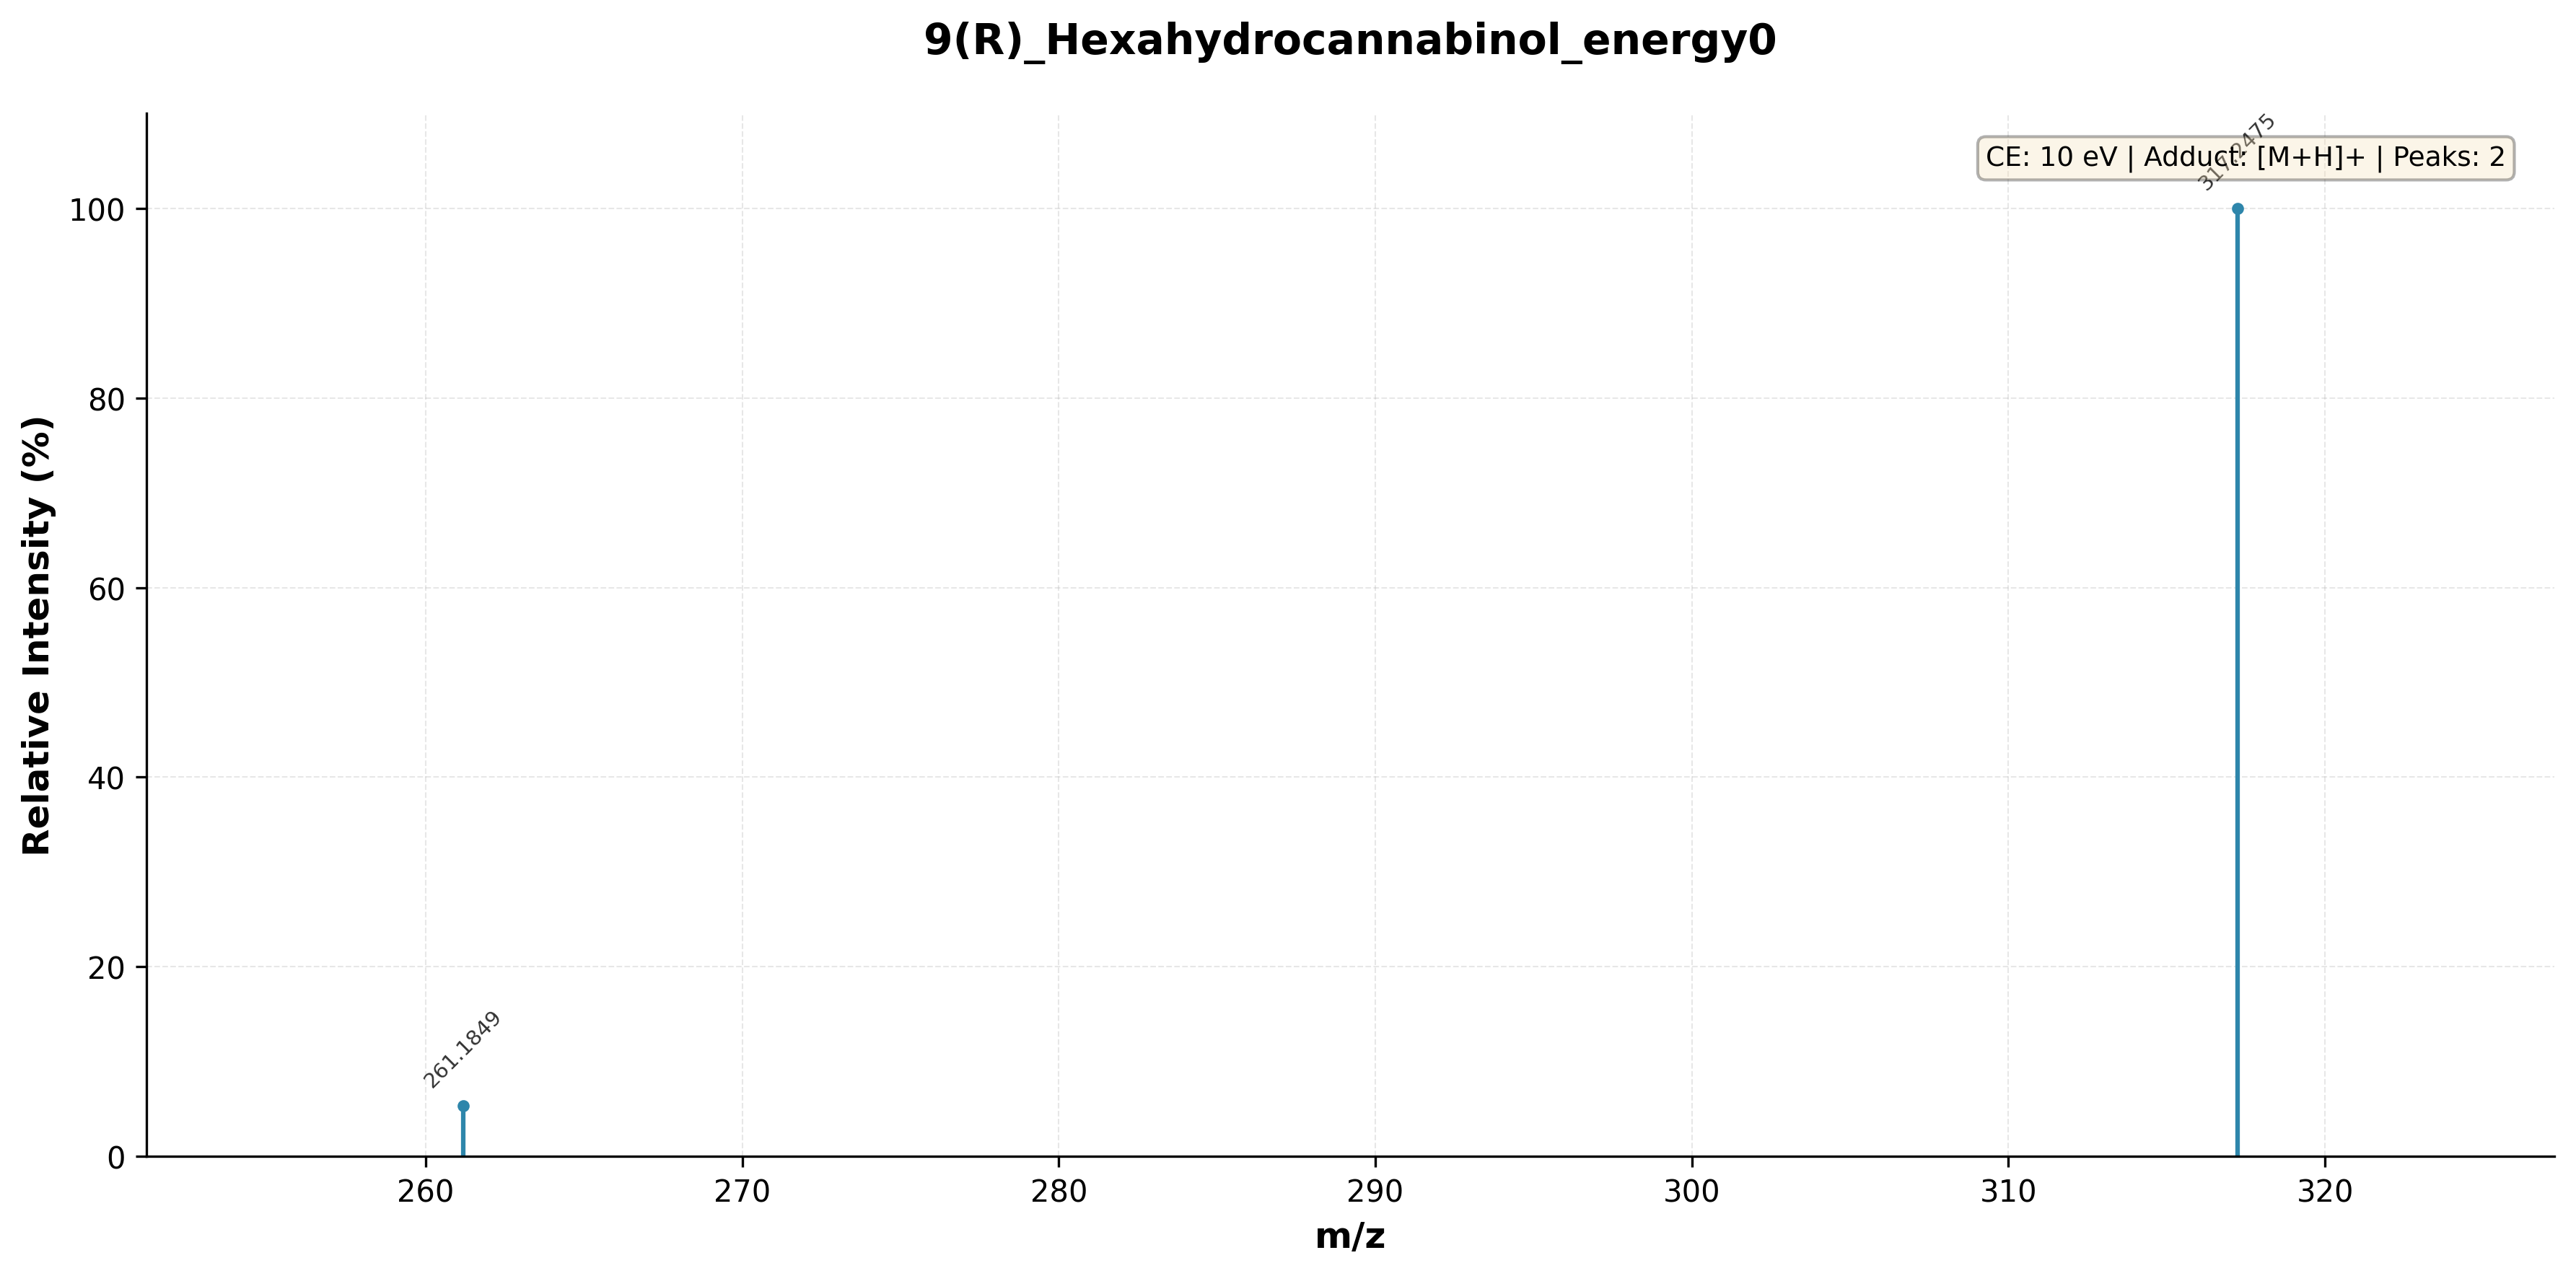


all_spectra (1)_9_R__Hexahydrocannabinol_energy1.png


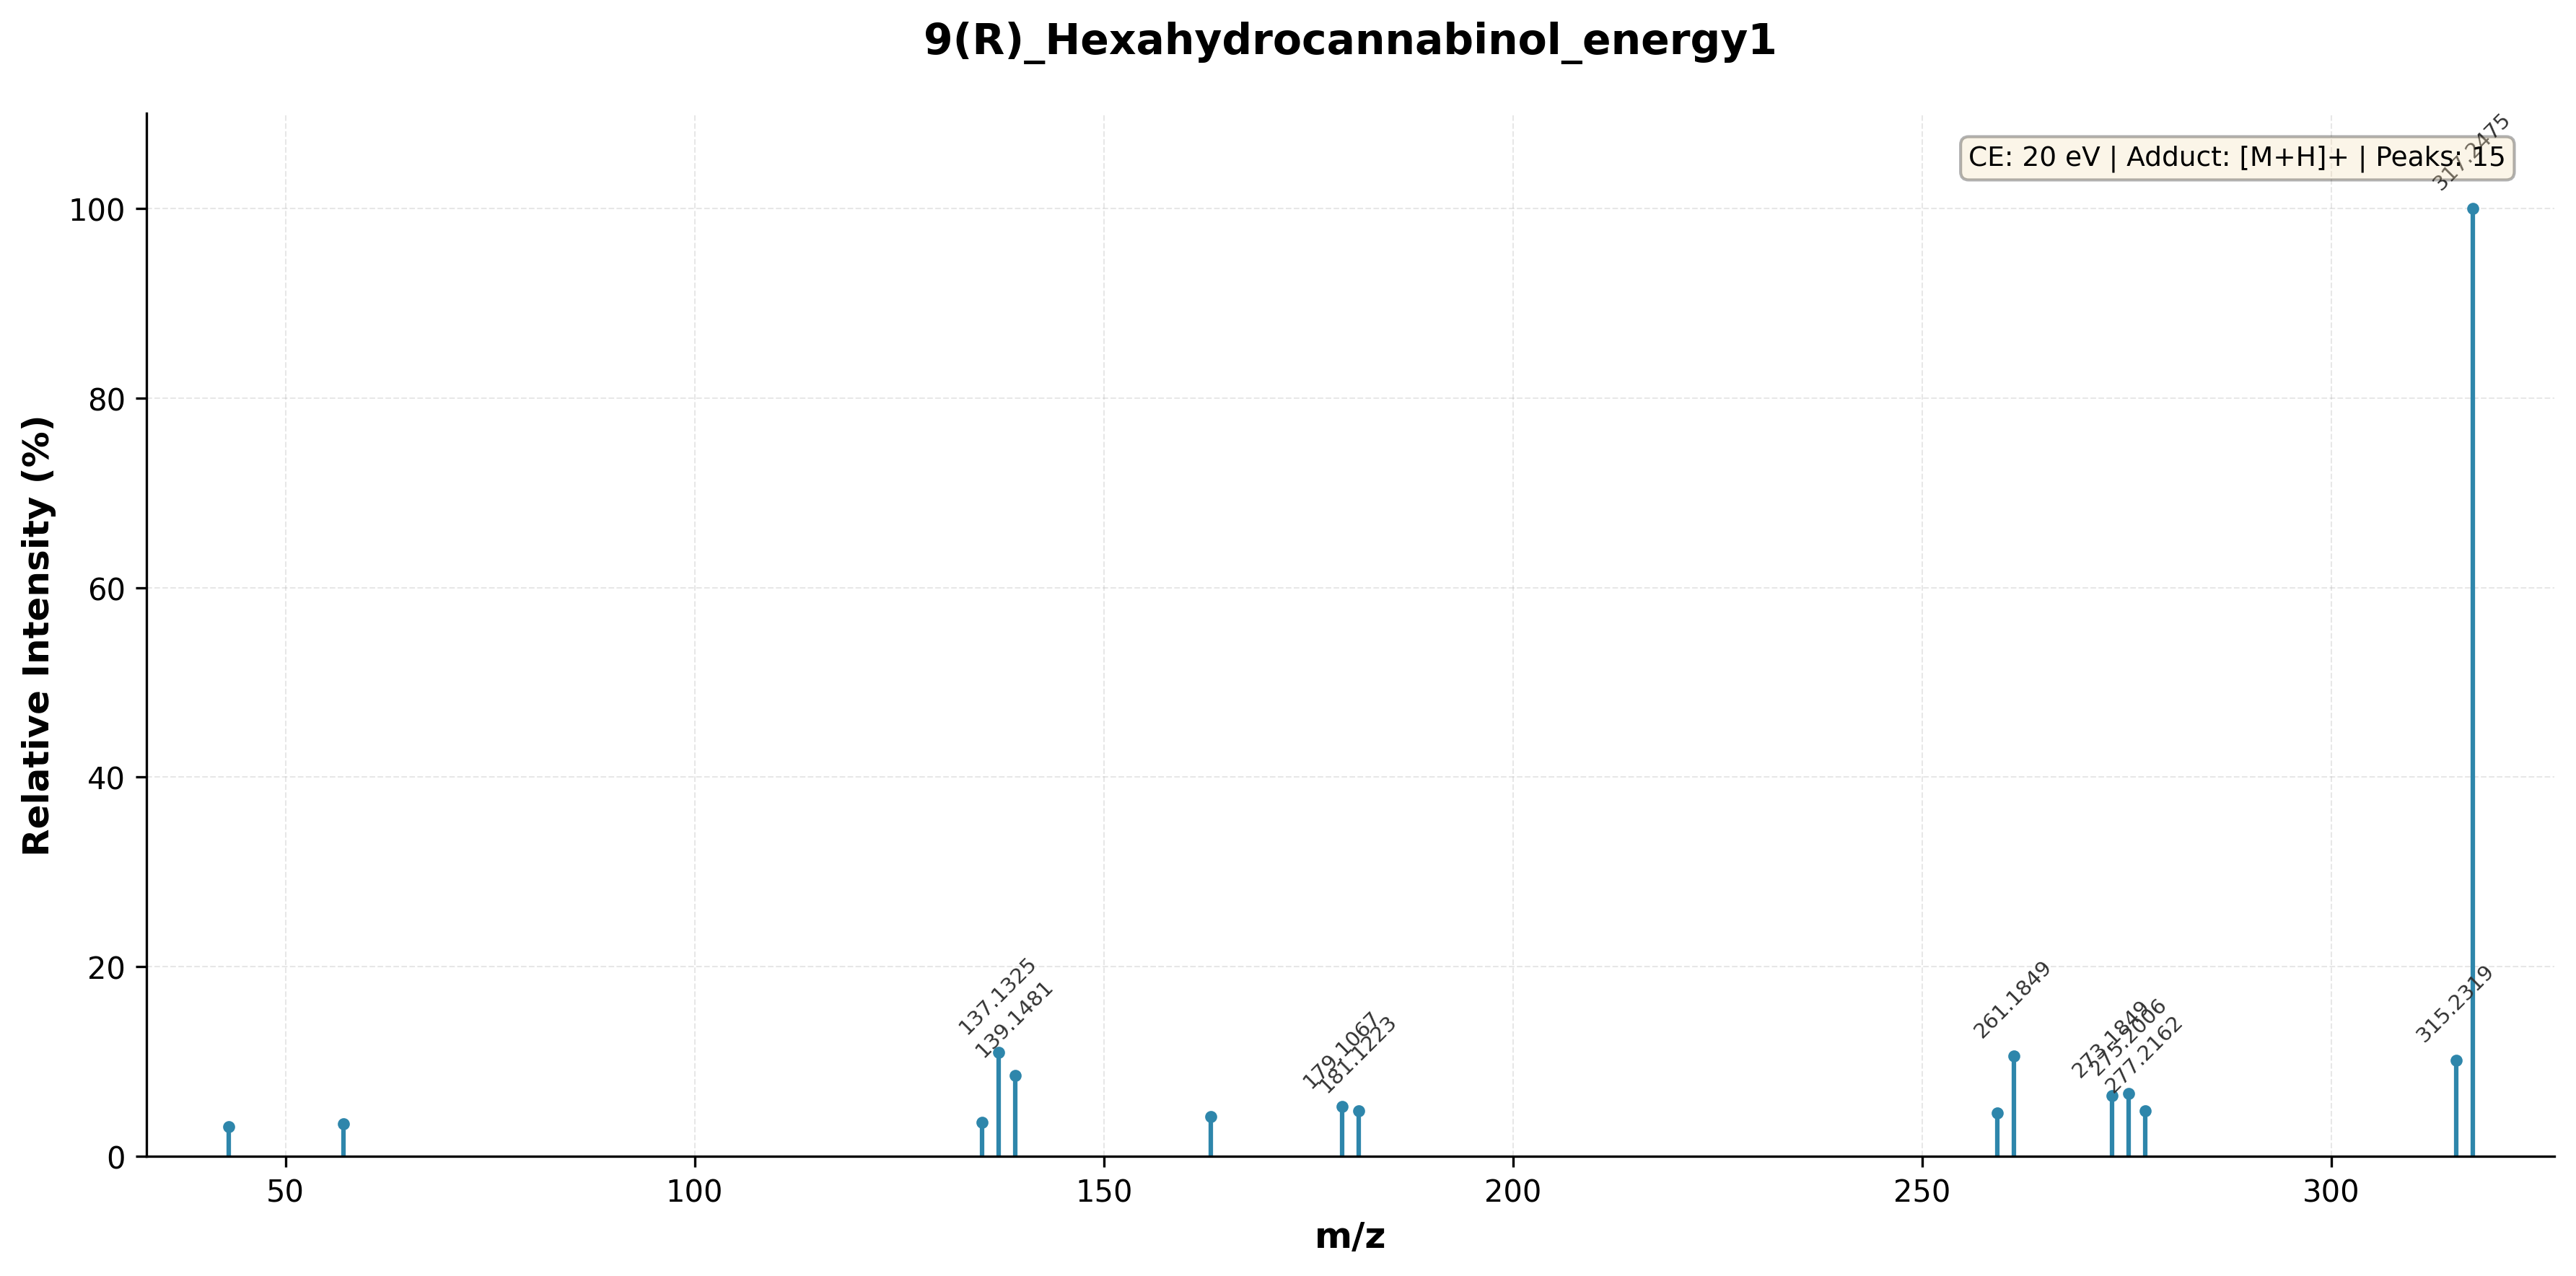


all_spectra (1)_9_R__Hexahydrocannabinol_energy2.png


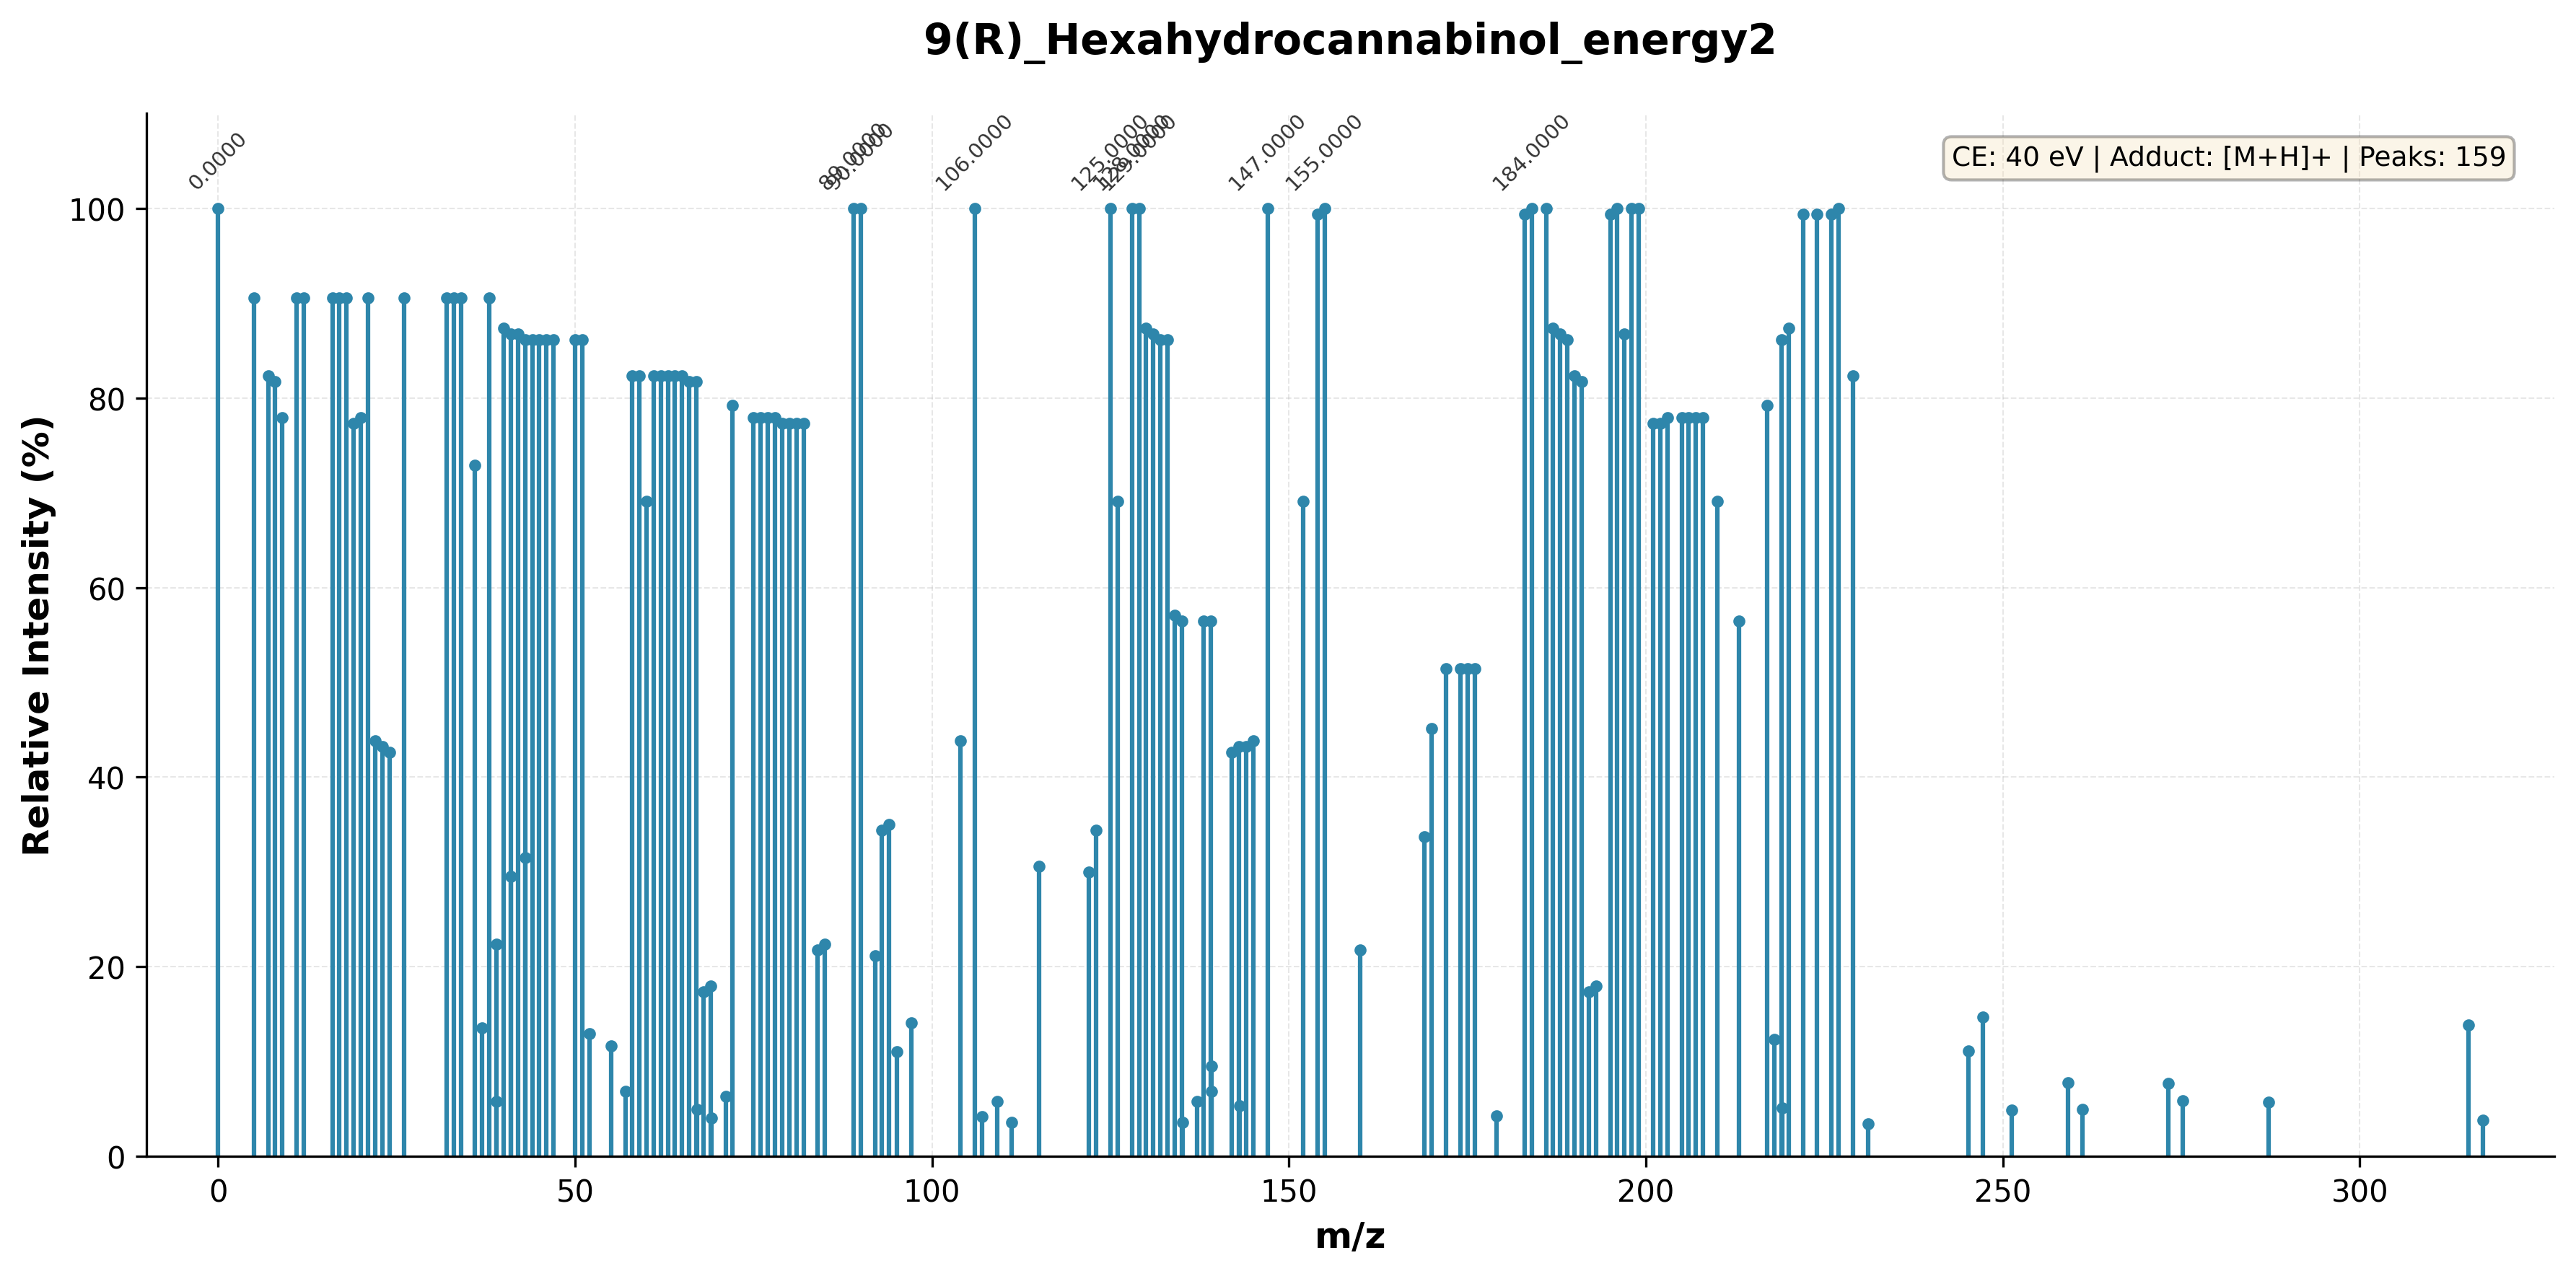


Done!


In [ ]:
import os
import re
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ============================================================================
# CONFIGURATION
# ============================================================================
FIGSIZE = (12, 6)
DPI = 300
ANNOTATE_TOP_N = 10  # Number of top peaks to annotate
MIN_INTENSITY_THRESHOLD = 1.0  # Only annotate peaks above this intensity
OUTPUT_DIR = "/content/spectra_plots/"

# ============================================================================
# MSP PARSER
# ============================================================================
def parse_msp_file(filepath: str) -> List[Dict]:
    """Parse MSP file and extract all spectra."""
    spectra = []
    current_spectrum = None
    reading_peaks = False

    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()

            if not line:
                if current_spectrum and current_spectrum.get('peaks'):
                    spectra.append(current_spectrum)
                current_spectrum = None
                reading_peaks = False
                continue

            if line.startswith('Name:'):
                current_spectrum = {
                    'name': line.split(':', 1)[1].strip(),
                    'metadata': {},
                    'peaks': []
                }
                reading_peaks = False

            elif current_spectrum is not None:
                if line.startswith('Comment:'):
                    current_spectrum['metadata']['comment'] = line.split(':', 1)[1].strip()

                elif line.startswith('Num Peaks:'):
                    try:
                        current_spectrum['num_peaks'] = int(line.split(':', 1)[1].strip())
                        reading_peaks = True
                    except ValueError:
                        pass

                elif reading_peaks:
                    # Try to parse as peak data (mz intensity)
                    parts = line.split()
                    if len(parts) >= 2:
                        try:
                            mz = float(parts[0])
                            intensity = float(parts[1])
                            annotation = parts[2] if len(parts) > 2 else ""
                            current_spectrum['peaks'].append((mz, intensity, annotation))
                        except (ValueError, IndexError):
                            reading_peaks = False

    # Add last spectrum if exists
    if current_spectrum and current_spectrum.get('peaks'):
        spectra.append(current_spectrum)

    return spectra

# ============================================================================
# CFM-ID LOG PARSER
# ============================================================================
def parse_cfm_log(filepath: str) -> List[Dict]:
    """Parse CFM-ID log file and extract spectra."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    metadata = {}
    for line in lines:
        if line.startswith('#ID='):
            metadata['id'] = line.split('=', 1)[1].strip()
        elif line.startswith('#InChI='):
            metadata['inchi'] = line.split('=', 1)[1].strip()
        elif line.startswith('#InChIKey='):
            metadata['inchikey'] = line.split('=', 1)[1].strip()

    spectra = []
    current_energy = None
    peaks = []

    i = 0
    while i < len(lines):
        line = lines[i].strip()

        energy_match = re.match(r'(energy[0-2])', line, re.IGNORECASE)
        if energy_match:
            if current_energy and peaks:
                spectra.append({
                    'name': f"{metadata.get('id', 'unknown')}_{current_energy}",
                    'energy': current_energy,
                    'peaks': peaks.copy(),
                    'metadata': metadata.copy()
                })
                peaks = []

            current_energy = energy_match.group(1).lower()
            i += 1
            continue

        if current_energy and line and not line.startswith('#'):
            parts = line.split()
            if len(parts) >= 2:
                try:
                    mz = float(parts[0])
                    intensity = float(parts[1])
                    if intensity > 0:
                        peaks.append((mz, intensity, ""))
                except (ValueError, IndexError):
                    pass

        i += 1

    if current_energy and peaks:
        spectra.append({
            'name': f"{metadata.get('id', 'unknown')}_{current_energy}",
            'energy': current_energy,
            'peaks': peaks.copy(),
            'metadata': metadata.copy()
        })

    return spectra

# ============================================================================
# SPECTRUM PROCESSING
# ============================================================================
def normalize_spectrum(peaks: List[Tuple]) -> List[Tuple[float, float, str]]:
    """Normalize peak intensities to 100 for base peak."""
    if not peaks:
        return []

    max_intensity = max(p[1] for p in peaks if len(p) >= 2)
    if max_intensity == 0:
        return []

    normalized = []
    for peak in peaks:
        mz = float(peak[0])
        intensity = (float(peak[1]) / max_intensity) * 100
        annotation = peak[2] if len(peak) > 2 else ""
        normalized.append((mz, intensity, annotation))

    return sorted(normalized, key=lambda x: x[0])

# ============================================================================
# PLOTTING FUNCTIONS
# ============================================================================
def plot_spectrum(spectrum: Dict, output_path: str):
    """Create a publication-quality MS spectrum plot."""
    peaks = normalize_spectrum(spectrum['peaks'])

    if not peaks:
        print(f"  Warning: No peaks to plot for {spectrum['name']}")
        return

    mz_values = [p[0] for p in peaks]
    intensities = [p[1] for p in peaks]

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

    # Plot spectrum as stem plot
    markerline, stemlines, baseline = ax.stem(
        mz_values,
        intensities,
        linefmt='#2E86AB',
        markerfmt='o',
        basefmt=' '
    )
    plt.setp(stemlines, linewidth=1.5)
    plt.setp(markerline, markersize=3, color='#2E86AB')

    # Annotate top peaks
    top_peaks = sorted(peaks, key=lambda x: x[1], reverse=True)[:ANNOTATE_TOP_N]
    top_peaks = [p for p in top_peaks if p[1] >= MIN_INTENSITY_THRESHOLD]

    for mz, intensity, annotation in top_peaks:
        ax.annotate(
            f'{mz:.4f}',
            xy=(mz, intensity),
            xytext=(0, 5),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=7,
            rotation=45,
            color='#333333'
        )

    # Styling
    ax.set_xlabel('m/z', fontsize=12, fontweight='bold')
    ax.set_ylabel('Relative Intensity (%)', fontsize=12, fontweight='bold')
    ax.set_title(spectrum['name'], fontsize=14, fontweight='bold', pad=20)

    ax.set_ylim(0, 110)
    ax.set_xlim(min(mz_values) - 10, max(mz_values) + 10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

    # Add metadata text box
    metadata_text = []
    if 'metadata' in spectrum:
        comment = spectrum['metadata'].get('comment', '')
        if 'CollisionEnergy' in comment:
            ce_match = re.search(r'CollisionEnergy(?:Approx)?=(\d+)', comment)
            if ce_match:
                metadata_text.append(f"CE: {ce_match.group(1)} eV")
        if 'Adduct' in comment:
            adduct_match = re.search(r'Adduct=([^\s;]+)', comment)
            if adduct_match:
                metadata_text.append(f"Adduct: {adduct_match.group(1)}")

    metadata_text.append(f"Peaks: {len(peaks)}")

    if metadata_text:
        textstr = ' | '.join(metadata_text)
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.3)
        ax.text(
            0.98, 0.97, textstr,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )

    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI, bbox_inches='tight')
    plt.close()

    print(f"  Saved: {output_path}")

def plot_mirror_spectrum(spectrum1: Dict, spectrum2: Dict, output_path: str):
    """Create mirror/head-to-tail comparison plot of two spectra."""
    peaks1 = normalize_spectrum(spectrum1['peaks'])
    peaks2 = normalize_spectrum(spectrum2['peaks'])

    if not peaks1 or not peaks2:
        print(f"  Warning: Insufficient peaks for mirror plot")
        return

    mz1 = [p[0] for p in peaks1]
    int1 = [p[1] for p in peaks1]
    mz2 = [p[0] for p in peaks2]
    int2 = [-p[1] for p in peaks2]  # Negative for mirror effect

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

    # Plot both spectra
    markerline1, stemlines1, _ = ax.stem(mz1, int1, linefmt='#A23B72', markerfmt='o', basefmt=' ')
    plt.setp(stemlines1, linewidth=1.5)
    plt.setp(markerline1, markersize=3, color='#A23B72')

    markerline2, stemlines2, _ = ax.stem(mz2, int2, linefmt='#2E86AB', markerfmt='o', basefmt=' ')
    plt.setp(stemlines2, linewidth=1.5)
    plt.setp(markerline2, markersize=3, color='#2E86AB')

    # Styling
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_xlabel('m/z', fontsize=12, fontweight='bold')
    ax.set_ylabel('Relative Intensity (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Mirror Plot: {spectrum1["name"]} vs {spectrum2["name"]}',
                 fontsize=13, fontweight='bold', pad=20)

    all_mz = mz1 + mz2
    ax.set_xlim(min(all_mz) - 10, max(all_mz) + 10)
    ax.set_ylim(-110, 110)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

    # Legend
    legend_elements = [
        mpatches.Patch(color='#A23B72', label=spectrum1['name']),
        mpatches.Patch(color='#2E86AB', label=spectrum2['name'])
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI, bbox_inches='tight')
    plt.close()

    print(f"  Saved: {output_path}")

# ============================================================================
# FILE PROCESSING
# ============================================================================
def process_file(filepath: str, create_mirror: bool = False) -> List[str]:
    """Process a single file and create plots."""
    output_files = []
    filename = Path(filepath).name
    file_stem = Path(filepath).stem

    print(f"\nProcessing: {filename}")

    # Determine file type and parse
    if filepath.endswith('.msp'):
        print("  Detected: MSP format")
        spectra = parse_msp_file(filepath)
    elif filepath.endswith('.log') or filepath.endswith('.txt'):
        print("  Detected: CFM-ID log format")
        spectra = parse_cfm_log(filepath)
    else:
        print(f"  Error: Unsupported file type")
        return output_files

    if not spectra:
        print(f"  Warning: No spectra found in file")
        return output_files

    print(f"  Found {len(spectra)} spectrum/spectra")

    # Create output directory
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Plot individual spectra
    for i, spectrum in enumerate(spectra):
        safe_name = re.sub(r'[^\w\-_]', '_', spectrum['name'])
        output_path = os.path.join(OUTPUT_DIR, f"{file_stem}_{safe_name}.png")

        try:
            plot_spectrum(spectrum, output_path)
            output_files.append(output_path)
        except Exception as e:
            print(f"  Error plotting {spectrum['name']}: {e}")

    # Create mirror plots if requested and multiple spectra exist
    if create_mirror and len(spectra) >= 2:
        print("\n  Creating mirror plots...")
        for i in range(len(spectra) - 1):
            safe_name1 = re.sub(r'[^\w\-_]', '_', spectra[i]['name'])
            safe_name2 = re.sub(r'[^\w\-_]', '_', spectra[i+1]['name'])
            output_path = os.path.join(
                OUTPUT_DIR,
                f"{file_stem}_mirror_{safe_name1}_vs_{safe_name2}.png"
            )

            try:
                plot_mirror_spectrum(spectra[i], spectra[i+1], output_path)
                output_files.append(output_path)
            except Exception as e:
                print(f"  Error creating mirror plot: {e}")

    return output_files

# ============================================================================
# MAIN EXECUTION
# ============================================================================
print("=" * 70)
print("MS SPECTRA VISUALIZATION TOOL")
print("=" * 70)
print("\nSupported formats: .msp (recommended), .log, .txt (CFM-ID format)")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Image format: PNG ({DPI} DPI)\n")

input_files = []

# File upload interface (Colab)
if IN_COLAB:
    print("Option 1: Upload files (.msp, .log, or .txt)")
    print("Option 2: Cancel to scan current directory\n")
    try:
        uploaded = files.upload()
        if uploaded:
            input_files = [f for f in uploaded.keys()
                          if f.endswith(('.msp', '.log', '.txt'))]
            print(f"\nUploaded {len(input_files)} file(s)")
    except Exception:
        print("\nNo upload, scanning directory...")

# Scan directory if no uploads
if not input_files:
    print("\nScanning /content/ for spectrum files...")
    for ext in ['*.msp', '*.log', '*.txt']:
        input_files.extend([str(f) for f in Path('/content/').glob(ext)])

    if input_files:
        print(f"Found {len(input_files)} file(s)")
    else:
        print("No spectrum files found!")

# Process files
if input_files:
    all_output_files = []

    # Ask about mirror plots
    CREATE_MIRRORS = True  # Set to False if you don't want mirror plots

    for input_file in input_files:
        try:
            output_files = process_file(input_file, create_mirror=CREATE_MIRRORS)
            all_output_files.extend(output_files)
        except Exception as e:
            print(f"\nError processing {input_file}: {e}")

    # Summary
    print("\n" + "=" * 70)
    print(f"PROCESSING COMPLETE")
    print("=" * 70)
    print(f"Total plots created: {len(all_output_files)}")
    print(f"Output location: {OUTPUT_DIR}")

    # Download files (Colab)
    if all_output_files and IN_COLAB:
        print("\n" + "=" * 70)
        print("DOWNLOADING FILES")
        print("=" * 70)

        # Create zip for batch download
        import zipfile
        zip_path = "/content/spectra_plots.zip"

        with zipfile.ZipFile(zip_path, 'w') as zipf:
            for file_path in all_output_files:
                zipf.write(file_path, Path(file_path).name)

        print(f"\nCreated zip archive: {zip_path}")
        print("Downloading...")

        try:
            files.download(zip_path)
            print("✓ Download complete!")
        except Exception as e:
            print(f"✗ Download failed: {e}")
            print("\nAlternatively, download individual files from the file browser")

    # Display sample plots in Colab
    if all_output_files and IN_COLAB:
        from IPython.display import Image, display
        print("\n" + "=" * 70)
        print("PREVIEW (showing first 3 plots)")
        print("=" * 70)
        for i, img_path in enumerate(all_output_files[:3]):
            print(f"\n{Path(img_path).name}")
            display(Image(filename=img_path))

else:
    print("\nNo files to process. Please upload or add spectrum files.")

print("\n" + "=" * 70)
print("Done!")
print("=" * 70)